In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('placement.csv')

In [3]:
df.shape

(1000, 3)

In [4]:
df.sample(5)

,cgpa,placement_exam_marks,placed
94,7.15,21.0,1
830,6.46,28.0,0
384,7.03,33.0,0
375,7.31,31.0,0
785,6.07,29.0,1


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

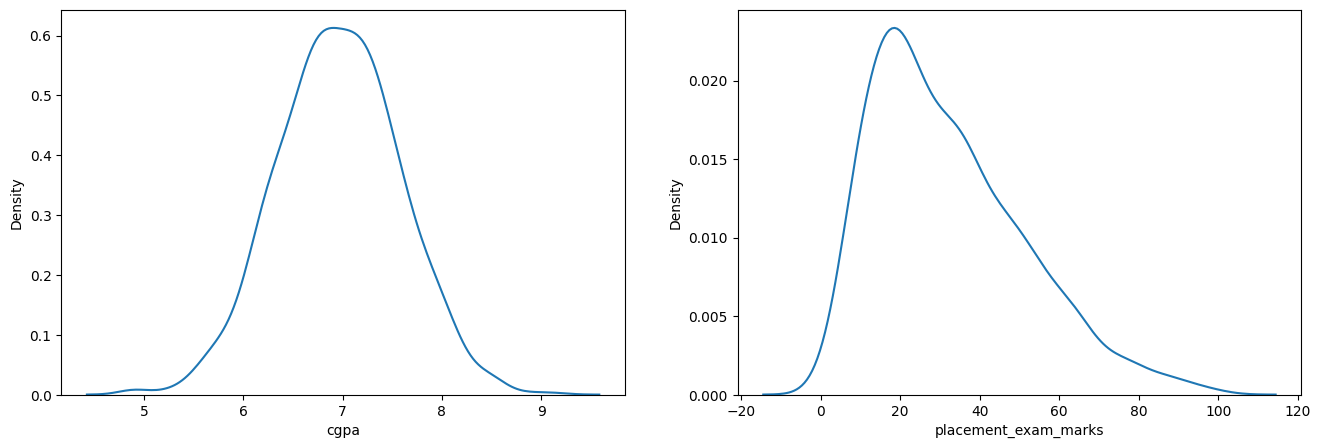

In [6]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(16,5))
sns.kdeplot(df['cgpa'],ax=ax1)
sns.kdeplot(df['placement_exam_marks'],ax=ax2)

<p>Only cgpa column in normally distributed so Z-score can be applied.</p>

<h1>Z-Score Method</h1>

In [7]:
df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [8]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


<h3>Trimming using Z-Score</h3>

In [9]:
new_df=df[(df['cgpa_zscore']<3)&(df['cgpa_zscore']>-3)]

In [11]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


<h1>Capping</h1>

In [12]:
up_lim=df['cgpa'].mean()+3*df['cgpa'].std()
low_lim=df['cgpa'].mean()-3*df['cgpa'].std()

In [13]:
up_lim

np.float64(8.808933625397168)

In [14]:
low_lim

np.float64(5.113546374602832)

In [15]:
df['cgpa']=np.where(df['cgpa']>up_lim,up_lim,
                    np.where(df['cgpa']<low_lim,low_lim,df['cgpa'])
                   )

In [16]:
df.shape

(1000, 4)

In [17]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

<p>Minimum value is 5.11 and Max value is 8.80 as expected after capping</p>

<h3>Trimming using Capping values</h3>

In [18]:
df1=pd.read_csv('placement.csv')

In [19]:
df1.sample(5)

,cgpa,placement_exam_marks,placed
965,7.37,52.0,1
637,7.25,74.0,0
79,7.63,19.0,1
55,8.12,15.0,0
596,8.48,25.0,1


In [20]:
up_lim=df['cgpa'].mean()+3*df['cgpa'].std()
low_lim=df['cgpa'].mean()-3*df['cgpa'].std()

In [21]:
up_lim

np.float64(8.799563584169265)

In [22]:
low_lim

np.float64(5.123433428579941)

In [23]:
new_df1=df1[(df1['cgpa']<8.79) & (df1['cgpa']>5.12)]

In [24]:
new_df1.shape

(995, 3)